<a href="https://colab.research.google.com/github/LeonimerMelo/Deep_Learning/blob/Artificial-Neural-Networks/Feedfoward_Neural_Network_%5BMNIST_Classification%5D_Deep_Learning_3_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Feedfoward  Neural  Network
Fully Connected Network
##Deep Learning (MNIST Classification) -  part #3

In [1]:
# importando as bibliotecas tradicionais mais utilizadas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist
# importando o MNIST digit dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('X_train:',X_train.shape)
print('y_train:',y_train.shape)
print('X_test:',X_test.shape)
print('y_test:',y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


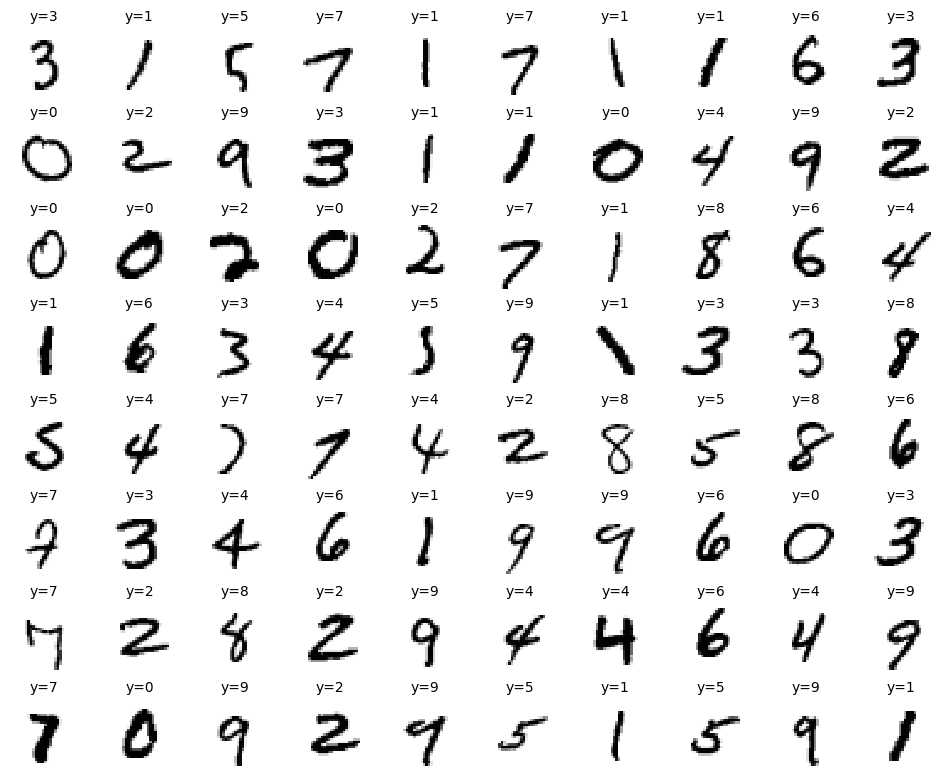

In [2]:
# Visualização de parte do dataset
class_names = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
n_rows = 8
n_cols = 10
rand = np.random.randint(100)
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index+rand], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title('y='+class_names[y_train[index+rand]], fontsize=10)
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

In [4]:
# outra maneira de visualização de parte aleatória do dataset
def show_data(examples, targets):
  samples = 80
  rand_num = np.random.randint(0, examples.shape[0] - samples)
  plt.figure(figsize = (8,8))
  for i in range(samples):
    plt.subplot(8, 10, i+1)
    plt.imshow(examples[rand_num + i], cmap = 'Greys')
    plt.xlabel(f"Label: {targets[rand_num + i]}")
    plt.xticks([])
    plt.yticks([])
  plt.tight_layout()
  plt.show()

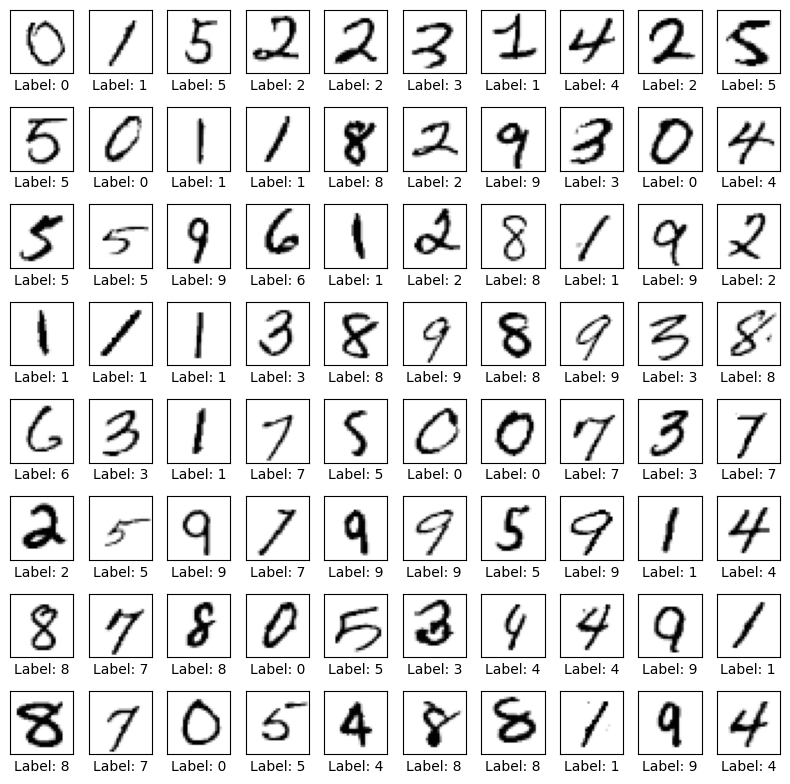

In [5]:
# 80 amostras randômicas do dataset
show_data(X_train, y_train)

In [6]:
# vetorização dos dados de entrada
# Redução da dimensão do tensor de 28x28 para 784
X_train_flat = X_train.reshape(60000, 784)
# outra maneira de se fazer o reshape de 28x28 para 784
X_test_flat = X_test.reshape(-1, 28*28)
print('X_train_flat:',X_train_flat.shape)
print('X_test_flat:',X_test_flat.shape)

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


In [7]:
# reescalonamento (normalização)
max_value = X_train.max()
print('Valor máximo do pixel:', max_value)
X_train_sc = X_train_flat / max_value
X_test_sc = X_test_flat / max_value
print(f'Valor mínimo do pixel após o reescalonamento: {X_train_sc.min()}')
print(f'Valor máximo do pixel após o reescalonamento: {X_train_sc.max()}')

Valor máximo do pixel: 255
Valor mínimo do pixel após o reescalonamento: 0.0
Valor máximo do pixel após o reescalonamento: 1.0


In [8]:
# TensorFlow Keras libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
import tensorflow.keras.backend as K

# Arquitetura da rede para os testes iniciais
# inicializa a sessão
K.clear_session()
# inicialização do modelo
model = Sequential(name='rede1')
# camada de entrada = 784 neurônios
model.add(Input((784,), name='input'))
# primeira hidden layer = 50 neurônios e função de ativação = relu
model.add(Dense(units = 50, activation = 'relu', name='layer1'))
# camada de saída
model.add(Dense(10, activation='softmax', name='output'))
# sumário do modelo da rede
model.summary()

Model: "rede1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compilação do modelo
# learning rate (eta)
eta = 0.01
# optimizer = Stocatisc Gradient Decent
optimizer_=SGD(eta)
# compilando o modelo da rede
# não faremos o categorical encoding nas classes (y) pois utilizaremos a função perda loss = 'sparse_categorical_crossentropy'
model.compile(optimizer = optimizer_, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
# salva os pesos e bias com os valores inicias
# model.save_weights('model.h5')
weights = model.get_weights()

In [10]:
# classes (target) com valores inteiros de 0 a 9
print('y train:', y_train[0:10])

y train: [5 0 4 1 9 2 1 3 1 4]


In [ ]:
# para medição do tempo de treinamento
import time
# início do treinamento da rede
start_time = time.process_time()
# carrega os pesos e bias com os valores inicias, para um novo treinamento da rede
model.set_weights(weights)
# treinamento da rede
h = model.fit(X_train_sc, y_train, batch_size=128, epochs=10, verbose=1, validation_split=0.1)
# tempo total de treinamento da rede
training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento da rede: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6806 - loss: 1.2850 - val_accuracy: 0.8695 - val_loss: 0.6608
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8561 - loss: 0.5949 - val_accuracy: 0.8998 - val_loss: 0.4313
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8759 - loss: 0.4658 - val_accuracy: 0.9093 - val_loss: 0.3596
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8872 - loss: 0.4114 - val_accuracy: 0.9157 - val_loss: 0.3233
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8952 - loss: 0.3794 - val_accuracy: 0.9195 - val_loss: 0.3006
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8998 - loss: 0.3575 - val_accuracy: 0.9238 - val_loss: 0.2846
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9041 - loss: 0.3409 - val_accuracy: 0.9255 - val_loss: 0.2722
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9070 - loss: 0.3276 - val_accuracy: 0.

In [22]:
# plot graphs function
def plot_graphs():
  plt.figure(figsize = (11,5))
  plt.subplot(1,2,1)
  plt.plot(h.history['loss'], label = 'Treino')
  plt.plot(h.history['val_loss'], label = 'Validação')
  plt.xlabel('Épocas')
  plt.ylabel('Função Custo')
  plt.title('loss')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.grid()
  plt.subplot(1,2,2)
  plt.plot(h.history['accuracy'], label = 'Treino')
  plt.plot(h.history['val_accuracy'], label = 'Validação')
  plt.xlabel('Épocas')
  plt.ylabel('Acurácia')
  plt.title('accuracy')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.tight_layout()
  plt.grid()
  plt.show()

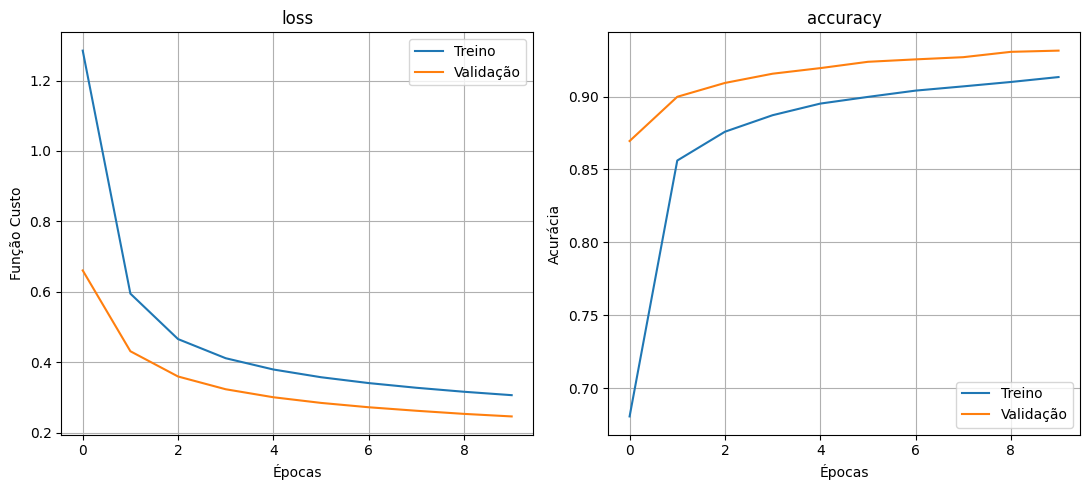

In [ ]:
plot_graphs()

In [ ]:
from sklearn.metrics import accuracy_score
# utilizando o modelo treinado para fazer as predições no banco de dados de testes
prediction = model.predict(X_test_sc)
y_predict = np.argmax(prediction,axis=1)
# cálculo da acurrácia das predições no banco de teste
acc = accuracy_score(y_test, y_predict)
print(f'acurárica: {acc*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
acurárica: 92.02%


### Análise dos resultados do treinamento — MNIST

- Convergência: a função de custo (loss) diminui continuamente, enquanto a acurácia aumenta, indicando que a rede está aprendendo adequadamente.
- Desempenho: a acurácia de validação atinge aproximadamente 93%, enquanto a de treinamento fica em torno de 91,5%.
- Generalização: a validação apresenta resultados melhores que o treinamento, sugerindo boa capacidade de generalização, devido a diferenças no comportamento do modelo durante treinamento e validação.
- Overfitting: não há sinais evidentes de sobreajuste, pois a perda de validação continua diminuindo e sua acurácia permanece crescente.
- Melhorias: seria possível investigar o aumento do número de épocas, ajustar os hiperparâmetros ou utilizar uma arquitetura mais profunda para melhorar o reconhecimento dos dígitos.

##Otimização dos parâmetros da rede
### Taxa de aprendizagem (Learning Rate)
Let's explore what happens to the performance of our model if we change the learning rate. We can do this with a simple loop where we perform the following steps:

1. We recompile the model with a different learning rate.
1. We reset the weights to the initial value.
1. We retrain the model and append the results to a list.

In [ ]:
# fitting the model with different learning rates
start_time = time.process_time()
dflist = []
learning_rates = [0.01, 0.05, 0.1, 0.5]
for lr in learning_rates:
  inter_time = time.process_time()
  # compilo o modelo com o learning rate a ser uitlizado
  model.compile(optimizer = SGD(learning_rate=lr), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
  # inicializo os pesos
  model.set_weights(weights)
  # treino o modelo
  h = model.fit(X_train_sc, y_train, batch_size=128, epochs=10, verbose=0, validation_split=0.1)
  # salvo o resultado do treinamento em um data frame pandas
  dflist.append(pd.DataFrame(h.history, index=h.epoch))
  print("Done: {}".format(lr))

  training_time_s = time.process_time() - inter_time
  training_time_m = training_time_s / 60
  print("Tempo: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento total: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Done: 0.01
Tempo: 14.55 segundos (0.24 minutos)
Done: 0.05
Tempo: 14.43 segundos (0.24 minutos)
Done: 0.1
Tempo: 14.61 segundos (0.24 minutos)
Done: 0.5
Tempo: 14.74 segundos (0.25 minutos)

Tempo de treinamento total: 58.33 segundos (0.97 minutos)


We can concatenate all our results in a single file for easy visualization using the `pd.concat` function along the columns axis.

In [ ]:
historydf = pd.concat(dflist, axis=1)
historydf

,accuracy,loss,val_accuracy,val_loss,accuracy,loss,val_accuracy,val_loss,accuracy,loss,val_accuracy,val_loss,accuracy,loss,val_accuracy,val_loss
0,0.658778,1.324956,0.850667,0.705456,0.824963,0.659001,0.915833,0.315508,0.859815,0.513023,0.926833,0.262643,0.891463,0.356173,0.959167,0.151652
1,0.842704,0.633075,0.890333,0.461791,0.902278,0.345817,0.928000,0.260060,0.918481,0.287887,0.939667,0.217873,0.951852,0.164040,0.963833,0.128538
2,0.870852,0.489768,0.906333,0.379057,0.915296,0.300064,0.933667,0.234125,0.932870,0.239509,0.948500,0.188847,0.961889,0.125932,0.969000,0.108231
3,0.884889,0.427859,0.912000,0.338389,0.923389,0.271224,0.940333,0.212936,0.941556,0.207333,0.955167,0.165402,0.968815,0.104383,0.970667,0.102438
4,0.892296,0.392361,0.916833,0.314234,0.930407,0.248582,0.946667,0.198392,0.948111,0.184210,0.959167,0.150123,0.972926,0.090025,0.972333,0.099241
5,0.897556,0.368632,0.918833,0.296545,0.935667,0.229715,0.949833,0.187849,0.952611,0.166660,0.961833,0.138114,0.975963,0.078977,0.973667,0.099415
6,0.902185,0.351377,0.922333,0.284512,0.940593,0.213846,0.953833,0.174293,0.956759,0.151437,0.965167,0.130399,0.978093,0.072204,0.973667,0.096120
7,0.905259,0.337734,0.923333,0.273882,0.944370,0.200064,0.956333,0.166128,0.960593,0.139645,0.967333,0.126212,0.980222,0.063763,0.974833,0.094034
8,0.908093,0.326692,0.924667,0.265134,0.946759,0.188495,0.957500,0.159051,0.963389,0.129412,0.966667,0.118837,0.981685,0.058666,0.975333,0.093675
9,0.910815,0.317131,0.927000,0.257847,0.949685,0.178504,0.958833,0.151735,0.965074,0.121079,0.969333,0.113282,0.983907,0.052129,0.977000,0.090007


And we can add information about the learning rate in a secondary column index using the `pd.MultiIndex` class.

In [ ]:
metrics_reported = dflist[0].columns
idx = pd.MultiIndex.from_product([learning_rates, metrics_reported], names=['learning_rate', 'metric'])
historydf.columns = idx
historydf

learning_rate      0.01                                       0.05            \
metric         accuracy      loss val_accuracy  val_loss  accuracy      loss   
0              0.658778  1.324956     0.850667  0.705456  0.824963  0.659001   
1              0.842704  0.633075     0.890333  0.461791  0.902278  0.345817   
2              0.870852  0.489768     0.906333  0.379057  0.915296  0.300064   
3              0.884889  0.427859     0.912000  0.338389  0.923389  0.271224   
4              0.892296  0.392361     0.916833  0.314234  0.930407  0.248582   
5              0.897556  0.368632     0.918833  0.296545  0.935667  0.229715   
6              0.902185  0.351377     0.922333  0.284512  0.940593  0.213846   
7              0.905259  0.337734     0.923333  0.273882  0.944370  0.200064   
8              0.908093  0.326692     0.924667  0.265134  0.946759  0.188495   
9              0.910815  0.317131     0.927000  0.257847  0.949685  0.178504   

learning_rate                             0.10                         \
metric        val_accuracy  val_loss  accuracy      loss val_accuracy   
0                 0.915833  0.315508  0.859815  0.513023     0.926833   
1                 0.928000  0.260060  0.918481  0.287887     0.939667   
2                 0.933667  0.234125  0.932870  0.239509     0.948500   
3                 0.940333  0.212936  0.941556  0.207333     0.955167   
4                 0.946667  0.198392  0.948111  0.184210     0.959167   
5                 0.949833  0.187849  0.952611  0.166660     0.961833   
6                 0.953833  0.174293  0.956759  0.151437     0.965167   
7                 0.956333  0.166128  0.960593  0.139645     0.967333   
8                 0.957500  0.159051  0.963389  0.129412     0.966667   
9                 0.958833  0.151735  0.965074  0.121079     0.969333   

learning_rate                0.50                                   
metric         val_loss  accuracy      loss val_accuracy  val_loss  
0              0.262643  0.891463  0.356173     0.959167  0.151652  
1              0.217873  0.951852  0.164040     0.963833  0.128538  
2              0.188847  0.961889  0.125932     0.969000  0.108231  
3              0.165402  0.968815  0.104383     0.970667  0.102438  
4              0.150123  0.972926  0.090025     0.972333  0.099241  
5              0.138114  0.975963  0.078977     0.973667  0.099415  
6              0.130399  0.978093  0.072204     0.973667  0.096120  
7              0.126212  0.980222  0.063763     0.974833  0.094034  
8              0.118837  0.981685  0.058666     0.975333  0.093675  
9              0.113282  0.983907  0.052129     0.977000  0.090007

Now we can display the behavior of loss and accuracy as a function of the learning rate.

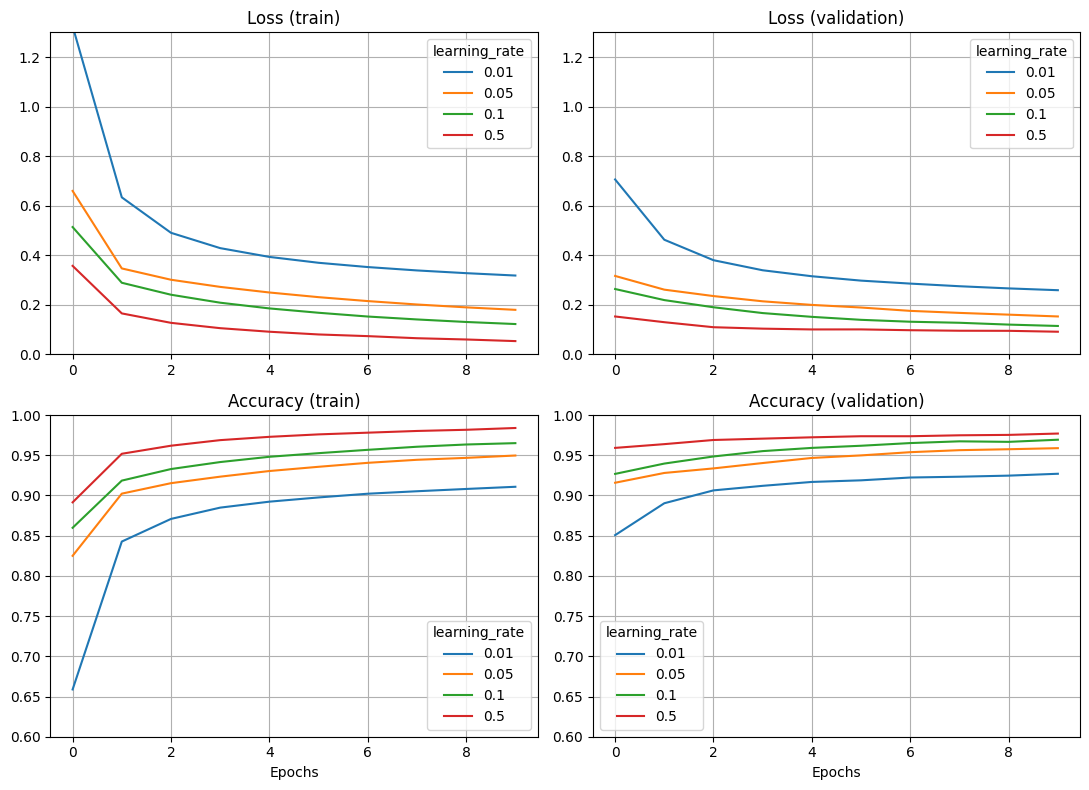

In [ ]:
fig = plt.figure(figsize = (11,8))
ax = plt.subplot(221)
hxs = historydf.xs('loss', axis=1, level='metric')
hxs.plot(ylim=(0,1.3), ax=ax)
plt.title("Loss (train)")
plt.grid()

ax = plt.subplot(222)
hxs = historydf.xs('val_loss', axis=1, level='metric')
hxs.plot(ylim=(0,1.3), ax=ax)
plt.title("Loss (validation)")
plt.grid()

ax = plt.subplot(223)
hxs = historydf.xs('accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.6,1), ax=ax)
plt.title("Accuracy (train)")
plt.xlabel("Epochs")
plt.grid()

ax = plt.subplot(224)
hxs = historydf.xs('val_accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.6,1), ax=ax)
plt.title("Accuracy (validation)")
plt.xlabel("Epochs")
plt.grid()

plt.tight_layout()
plt.show()

As expected a small learning rate gives a much slower decrease in the loss. Another hyperparameter we can try to tune is the **Batch Size**. Let's see how changing batch size affects the convergence of the model.

### Batch Sizes

Let's loop over increasing batch sizes from `32` points up to `256`.

In [ ]:
dflist = []
# learning rate
lr = 0.1
start_time = time.process_time()
# batch_sizes = [1, 8, 32, 128]
batch_sizes = [16, 32, 64, 128, 256]
# compilo o modelo com o learning rate a ser uitlizado
model.compile(optimizer = SGD(learning_rate=lr), loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

for batch_size in batch_sizes:
    inter_time = time.process_time()
    # inicializo os pesos
    model.set_weights(weights)
    # treino o modelo com diferentes batch sizes
    h = model.fit(X_train_sc, y_train, batch_size=batch_size, epochs=10, verbose=0, validation_split=0.1)
    # salvo o resultado do treinamento em um data frame pandas
    dflist.append(pd.DataFrame(h.history, index=h.epoch))
    print("Done: {}".format(batch_size))

    training_time_s = time.process_time() - inter_time
    training_time_m = training_time_s / 60
    print("Tempo: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento total: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Done: 16
Tempo: 94.49 segundos (1.57 minutos)
Done: 32
Tempo: 49.32 segundos (0.82 minutos)
Done: 64
Tempo: 26.31 segundos (0.44 minutos)
Done: 128
Tempo: 14.52 segundos (0.24 minutos)
Done: 256
Tempo: 9.15 segundos (0.15 minutos)

Tempo de treinamento total: 193.80 segundos (3.23 minutos)


Like we did above we can arrange the results in a `Pandas` Dataframe for easy display. Notice how we are using the `pd.MultiIndex.from_product` function to create a multi-index for the columns so that the data is organized by batch size and by metric.

In [ ]:
historydf = pd.concat(dflist, axis=1)
metrics_reported = dflist[0].columns
idx = pd.MultiIndex.from_product([batch_sizes, metrics_reported], names=['batch_size', 'metric'])
historydf.columns = idx
historydf

batch_size       16                                         32             \
metric      accuracy      loss val_accuracy  val_loss  accuracy      loss   
0           0.916222  0.281196     0.961833  0.134608  0.902389  0.337694   
1           0.958000  0.140369     0.968167  0.122182  0.948000  0.179246   
2           0.968444  0.105724     0.973167  0.094551  0.960148  0.135217   
3           0.973278  0.087555     0.974500  0.092901  0.967037  0.109606   
4           0.977185  0.073060     0.972833  0.099275  0.972685  0.091837   
5           0.980259  0.062895     0.976333  0.093350  0.974963  0.079201   
6           0.982074  0.057771     0.977167  0.097904  0.978778  0.069844   
7           0.984019  0.050302     0.974833  0.094836  0.980593  0.062669   
8           0.985556  0.045458     0.974667  0.094474  0.982870  0.056211   
9           0.987611  0.040218     0.973000  0.097756  0.984481  0.051575   

batch_size                              64                                    \
metric     val_accuracy  val_loss  accuracy      loss val_accuracy  val_loss   
0              0.948000  0.182206  0.883185  0.412135     0.938667  0.216560   
1              0.964333  0.133470  0.934148  0.230929     0.955667  0.167016   
2              0.966833  0.117000  0.948130  0.181655     0.962833  0.141521   
3              0.972333  0.105490  0.956426  0.151320     0.966833  0.128177   
4              0.975167  0.096764  0.962407  0.131450     0.968667  0.115058   
5              0.975167  0.093153  0.966333  0.115968     0.970000  0.110305   
6              0.973333  0.095354  0.970333  0.103599     0.972500  0.101845   
7              0.974667  0.091027  0.972315  0.093911     0.973667  0.099300   
8              0.974167  0.098505  0.975167  0.085803     0.973667  0.100212   
9              0.976333  0.091794  0.977278  0.079261     0.974833  0.095428   

batch_size       128                                        256            \
metric      accuracy      loss val_accuracy  val_loss  accuracy      loss   
0           0.859852  0.512746     0.926500  0.263174  0.823093  0.667575   
1           0.917463  0.290432     0.939833  0.213491  0.903074  0.345409   
2           0.932667  0.241930     0.950000  0.185492  0.915852  0.298467   
3           0.940093  0.210461     0.954167  0.169826  0.924407  0.269637   
4           0.947352  0.186639     0.957833  0.153532  0.931000  0.246589   
5           0.951981  0.168856     0.962167  0.143294  0.936352  0.228094   
6           0.956574  0.153920     0.964667  0.130822  0.940982  0.212729   
7           0.959926  0.141981     0.966500  0.125036  0.944130  0.199438   
8           0.962481  0.131743     0.966667  0.123300  0.947000  0.188057   
9           0.964722  0.123423     0.967667  0.115499  0.950037  0.177792   

batch_size                         
metric     val_accuracy  val_loss  
0              0.916167  0.316829  
1              0.926667  0.259548  
2              0.934667  0.232375  
3              0.941000  0.212977  
4              0.945500  0.197459  
5              0.949333  0.184248  
6              0.953500  0.173318  
7              0.954833  0.165701  
8              0.957500  0.159392  
9              0.959500  0.150268

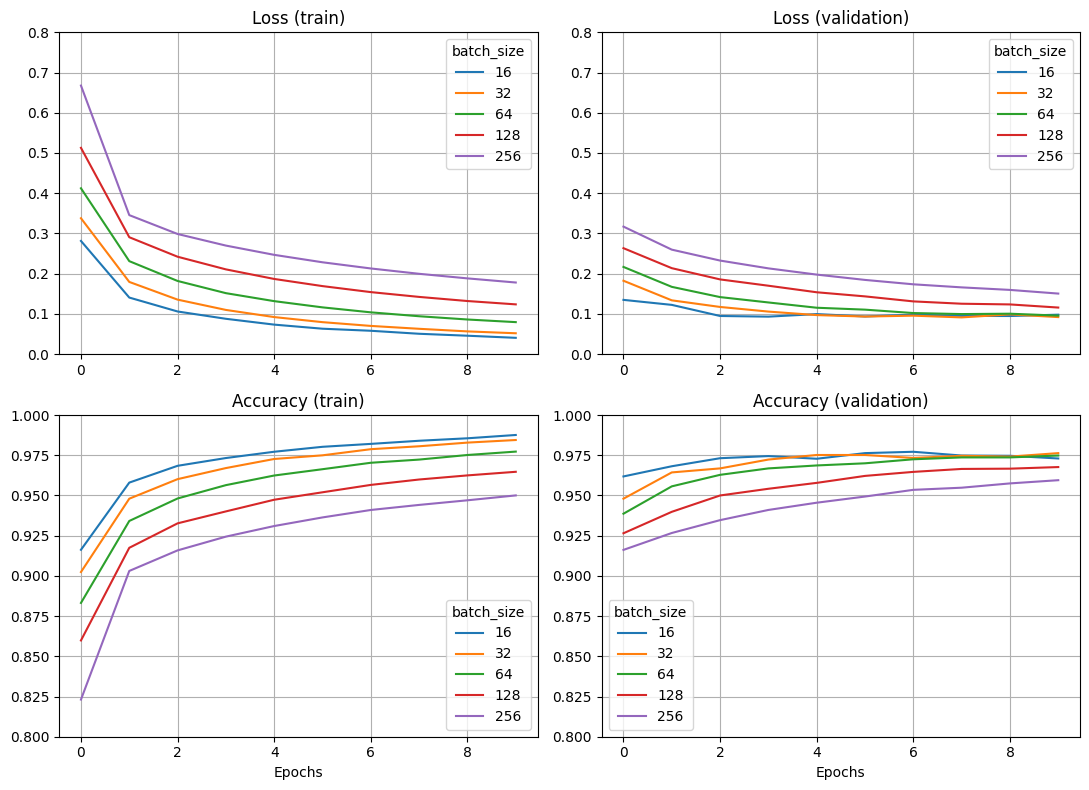

In [ ]:
fig = plt.figure(figsize = (11,8))
ax = plt.subplot(221)
hxs = historydf.xs('loss', axis=1, level='metric')
hxs.plot(ylim=(0,.8), ax=ax)
plt.title("Loss (train)")
plt.grid()

ax = plt.subplot(222)
hxs = historydf.xs('val_loss', axis=1, level='metric')
hxs.plot(ylim=(0,.8), ax=ax)
plt.title("Loss (validation)")
plt.grid()

ax = plt.subplot(223)
hxs = historydf.xs('accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.8,1), ax=ax)
plt.title("Accuracy (train)")
plt.xlabel("Epochs")
plt.grid()

ax = plt.subplot(224)
hxs = historydf.xs('val_accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.8,1), ax=ax)
plt.title("Accuracy (validation)")
plt.xlabel("Epochs")
plt.grid()

plt.tight_layout()
plt.show()

Smaller batches allow for more updates in a single epoch, on the other hand, they take much longer to run a single epoch, so there's a trade-off between speed of training (measured as number of gradients updates) and speed of convergence (measured as number of epochs). In practice a batch size of 16 or 32 data points is often used.

A [recent research article](https://arxiv.org/abs/1711.00489) suggests starting with a small batch size and the increase it gradually. We encourage you to try and experiment with that strategy as well.

##Optimizers in Deep Learning

O **Gradiente Descendente** (GD) e o **Gradiente Descendente Estocástico** (SGD) são dois algoritmos de otimização usados para treinar modelos de aprendizado de máquina. A principal diferença entre eles está na forma como são atualizados os parâmetros do modelo.

Gradiente Descendente (GD):

1. Utiliza todo o conjunto de treinamento para calcular o gradiente.
2. Atualiza os parâmetros após passar por todo o conjunto de treinamento.
3. Requer mais memória e computação.

Gradiente Descendente Estocástico (SGD):

1. Utiliza apenas uma amostra aleatória do conjunto de treinamento para calcular o gradiente.
2. Atualiza os parâmetros após cada amostra.
3. Requer menos memória e computação.

Vantagens do SGD:

1. Maior eficiência computacional.
2. Menor risco de sobreajuste (overfitting).
3. Possibilidade de convergência mais rápida.

Desvantagens do SGD:

1. Maior variância nos resultados.
2. Possibilidade de convergência para mínimos locais.

Quando usar cada um:

1. GD: Conjuntos de treinamento pequenos, problemas de otimização convexas.
2. SGD: Conjuntos de treinamento grandes, problemas de otimização não convexas.

Em resumo, o SGD é mais eficiente e escalável, mas pode ser mais instável. O GD é mais estável, mas pode ser mais lento e requer mais recursos.

###Gradient Descent (GD)
This is the most basic optimizer that directly uses the derivative of the loss function and learning rate to reduce the loss and achieve the minima. This approach is also adopted in backpropagation in neural networks where the updated parameters are shared between different layers depending upon when the minimum loss is achieved. It is easy to implement and interpret the results, but it has various issues.

The weights are updated when the whole dataset gradient is calculated, *which slows down the process*. It also requires a large amount of memory to store this temporary data, making it a resource-hungry process. Though the idea behind this algorithm is well suited, it needs to be tweaked.

###Stochastic Gradient Descent (SGD)
This is a changed version of the GD method, where the model parameters are updated on every iteration. It means that after every training sample, the loss function is tested and the model is updated. These frequent updates result in converging to the minima in less time, but it comes at the cost of increased variance that can make the model overshoot the required position.

But an advantage of this technique is low memory requirement as compared to the previous one because now there is no need to store the previous values of the loss functions.

A gradient descent optimizer may not be the best option for huge data. The stochastic gradient descent (SGD) optimizer tackles this problem. The term “stochastic” implies randomness upon which the algorithm is built upon. Rather than accepting the entire dataset for all iterations, a stochastic gradient allows you to choose the data’s batches randomly. It suggests that you only need to take a few samples from the dataset.

The process of this optimizer in neural network first selects the initial parameters ‘w’ and learning rate ‘n’. The data is then randomly shuffled at every iteration to obtain an approximate minimum.

Instead of the entire dataset, you only take the dataset’s batches for iteration. So, the path adopted by the algorithm consists of noise, unlike the gradient descent algorithm. Hence, SGD uses a higher number of iterations to attain the local minima. The total computation time increases because of an increase in the number of iterations. However, even after raising the number of iterations, the computation expense is still lesser than that of the GD optimizer. So, it concludes that an SGD optimizer in deep learning is preferable if the data is massive and the computational time is significant.

###Mini-Batch Gradient Descent
Another variant of this GD approach is mini-batch, where the model parameters are updated in small batch sizes. It means that after every n batches, the model parameters will be updated and this ensures that the model is proceeding towards minima in fewer steps without getting derailed often. This results in less memory usage and low variance in the model.

Rather than taking the whole training data, Mini-Batch Gradient Descent only takes a subset of the dataset to calculate the loss function. So, fewer iterations are required. Therefore, the mini-batch gradient descent algorithm is comparatively faster than both batch gradient descent and stochastic gradient descent algorithms.

It is more robust and efficient than the former variants of gradient descent algorithms. It uses batching, so all the training data need not be processed on the memory. Hence, this optimizer in neural network makes the process more efficient.

###Momentum Based Gradient Descent
O Momentum Based Gradient Descent (MBGD) é uma variante do algoritmo de Gradiente Descendente (GD) que incorpora o conceito de momentum para melhorar a convergência.

O que é momentum?

O momentum é uma medida da quantidade de movimento ou inércia que o algoritmo possui em uma direção específica. No contexto do MBGD, o momentum é usado para ajudar o algoritmo a superar os mínimos locais e evitar oscilações.

Como funciona o MBGD?

1. Inicialização: O algoritmo começa com um conjunto de parâmetros inicializados aleatoriamente.
2. Cálculo do gradiente: O gradiente do erro é calculado com respeito aos parâmetros.
3. Atualização do momentum: O momentum é atualizado com base no gradiente anterior e no momentum atual.
4. Atualização dos parâmetros: Os parâmetros são atualizados com base no momentum atualizado.

Equação do MBGD:

$$w(t+1) = w(t) - α * ∇E(w(t)) + γ * (w(t) - w(t-1))$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado
- $∇E(w(t))$ é o gradiente do erro no tempo t
- $γ$ é o parâmetro de momentum $(0 < γ < 1)$
- $w(t-1)$ é o vetor de parâmetros no tempo t-1

Vantagens do MBGD:

1. Melhor convergência: O MBGD pode superar os mínimos locais e evitar oscilações.
2. Maior estabilidade: O algoritmo é menos sensível a mudanças bruscas no gradiente.
3. Aceleração da convergência: O MBGD pode convergir mais rapidamente do que o GD.

Desvantagens do MBGD:

1. Maior complexidade: O algoritmo requer mais cálculos e memória.
2. Escolha do parâmetro de momentum: O valor de γ afeta significativamente o desempenho do algoritmo.

Aplicações do MBGD:

1. Otimização de funções não convexas
2. Treinamento de redes neurais
3. Otimização de problemas de otimização grande escala

Let’s revisit the method we are using to update the parameters. Based on the first-order derivative of the loss function, we are back-propagating the gradients. The frequency of updates can be after every iteration, a batch, or at the last, but we are not considering how many updates we have in the parameters.

If this history element is included in the next updates, then it can speed the whole process and this is what momentum means in this optimizer. This history element is like how our mind memorizes things. If you are walking on a street and you cover a pretty large distance, then you will be sure that your destination is some distance ahead and you will increase your speed.

This element depends on the previous value, learning rate, and a new parameter called gamma, which controls this history update. The update rule will be something like $w = w – v$, where v is the history element.

###Nesterov Accelerated Gradient (NAG)
O Nesterov Accelerated Gradient (NAG) é um algoritmo de otimização que combina o conceito de momentum com uma atualização anticipada dos parâmetros, proposto por Yurii Nesterov em 1983.

Equação do NAG:

$$w(t+1) = w(t) - α * ∇E(w(t) + γ * (w(t) - w(t-1))) + γ * (w(t) - w(t-1))$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado
- $∇E(w(t))$ é o gradiente do erro no tempo t
- $γ$ é o parâmetro de momentum $(0 < γ < 1)$
- $w(t-1)$ é o vetor de parâmetros no tempo t-1

Diferenças entre NAG e MBGD:

1. Atualização anticipada: NAG atualiza os parâmetros com base no gradiente calculado no ponto $w(t) + γ * (w(t) - w(t-1))$, enquanto MBGD atualiza com base no gradiente calculado no ponto $w(t)$.
2. Maior estabilidade: NAG é mais estável e menos sensível a mudanças bruscas no gradiente.

Vantagens do NAG:

1. Maior convergência: NAG converge mais rapidamente do que MBGD em muitos casos.
2. Melhor estabilidade: NAG é menos sensível a mudanças bruscas no gradiente.
3. Robustez: NAG é robusto em relação ao ruído no gradiente.

Desvantagens do NAG:

1. Maior complexidade: NAG requer mais cálculos e memória.
2. Escolha do parâmetro de momentum: O valor de γ afeta significativamente o desempenho do algoritmo.

The momentum-based GD gave a boost to the currently used optimizers by converging to the minima at the earliest, but it introduced a new problem. This method takes a lot of u-turns and oscillates in and out in the minima valley adding to the total time. The time taken is still way too less than normal GD, but this issue also needs a fix and this is done in NAG.  

The approach followed here was that the parameters update would be made with the history element first and then only the derivative is calculated which can move it in the forward or backward direction. This is called the look-ahead approach, and it makes more sense because if the curve reaches near to the minima, then the derivative can make it move slowly so that there are fewer oscillations and therefore saving more time.

###AdaGrad (Adaptive Gradient Descent)
AdaGrad (Adaptive Gradient Descent) é um algoritmo de otimização que ajusta a taxa de aprendizado para cada parâmetro individualmente, com base na magnitude do gradiente.

Motivação:

O Gradiente Descendente (GD) tradicional utiliza uma taxa de aprendizado fixa para todos os parâmetros. No entanto, isso pode levar a:

1. Aprendizado lento para parâmetros com gradientes pequenos.
2. Oscilações excessivas para parâmetros com gradientes grandes.

AdaGrad:

1. Inicialização: O algoritmo começa com um conjunto de parâmetros inicializados aleatoriamente.
2. Cálculo do gradiente: O gradiente do erro é calculado com respeito aos parâmetros.
3. Atualização da taxa de aprendizado: A taxa de aprendizado é ajustada para cada parâmetro individualmente, com base na magnitude do gradiente.

Equação do AdaGrad:

$$w(t+1) = w(t) - α * ∇E(w(t)) / \sqrt((G(t) + ε))$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado inicial
- $∇E(w(t))$ é o gradiente do erro no tempo t
- $G(t)$ é a soma acumulada dos quadrados dos gradientes até o tempo t
- $ε$ é um pequeno valor para evitar divisão por zero

Vantagens do AdaGrad:

1. Ajuste automático da taxa de aprendizado.
2. Melhor convergência para problemas com gradientes desbalanceados.
3. Robustez em relação ao ruído no gradiente.

Desvantagens do AdaGrad:

1. Diminuição da taxa de aprendizado ao longo do tempo.
2. Sensibilidade ao valor de α.

Aplicações do AdaGrad:

1. Otimização de funções não convexas.
2. Treinamento de redes neurais.
3. Otimização de problemas de otimização grande escala.

Comparação com outros algoritmos:

1. Gradiente Descendente (GD): AdaGrad ajusta a taxa de aprendizado individualmente.
2. Nesterov Accelerated Gradient (NAG): AdaGrad não utiliza momentum.
3. Adam: AdaGrad é mais simples e não utiliza momentum.

Till now we are only focusing on how the model parameters are affecting our training, but we haven’t talked about the hyper-parameters that are assigned constant value throughout the training. One such important hyper-parameter is **learning rate** and varying this can change the pace of training.

For a sparse feature input where most of the values are zero, we can afford a higher learning rate which will boost the dying gradient resulted from these sparse features. If we have dense data, then we can have slower learning.

The solution for this is to have an adaptive learning rate that can change according to the input provided. Adagrad optimizer tries to offer this adaptiveness by decaying the learning rate in proportion to the updated history of the gradients.

It means that when there are larger updates, the history element is accumulated, and therefore it reduces the learning rate and vice versa. One disadvantage of this approach is that the learning rate decays aggressively and after some time it approaches zero.

It uses unique learning rates for every iteration. The modification in learning rate depends on the variance in the parameters during the training. If the parameters change frequently, the learning rate, too, changes frequently. This change is advantageous because practical datasets include dense and sparse features. Hence, it is impartial to assign the same value of the learning rate for every feature.

One of the key benefits of using Adagrad optimizer in neural networks is that it does not need manual modification of the learning rate. It is more reliable than the gradient descent algorithms and their other variants. Moreover, it attains convergence at a faster speed.

###RMS-Prop (Root Mean Square Propagation)
RMSProp (Root Mean Square Propagation) é um algoritmo de otimização que combina os conceitos de Gradiente Descendente e AdaGrad, proposto por Geoffrey Hinton em 2012.

Motivação:

AdaGrad tem dois problemas principais:

1. Diminuição da taxa de aprendizado ao longo do tempo.
2. Sensibilidade ao valor de α.

RMSProp resolve esses problemas utilizando:

1. Uma média móvel dos quadrados dos gradientes.
2. Uma taxa de aprendizado adaptativa baseada na razão entre a média dos quadrados dos gradientes atuais e anteriores.

Equação do RMSProp:

$$w(t+1) = w(t) - α * ∇E(w(t)) / √(v(t) + ε)$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado inicial
- $∇E(w(t))$ é o gradiente do erro no tempo t
- $v(t)$ é a média móvel dos quadrados dos gradientes até o tempo t
- $ε$ é um pequeno valor para evitar divisão por zero

Atualização da média móvel dos quadrados dos gradientes:

$$v(t) = γ * v(t-1) + (1-γ) * g^2(t)$$

onde:

- $γ$ é o fator de esquecimento $(0 < γ < 1)$
- $g(t)$ é o gradiente no tempo t

Vantagens do RMSProp:

1. Ajuste automático da taxa de aprendizado.
2. Não requer ajuste do parâmetro α.
3. Robustez em relação ao ruído no gradiente.
4. Melhor convergência do que AdaGrad.

Desvantagens do RMSProp:

1. Requer mais memória para armazenar a média móvel dos quadrados dos gradientes.
2. Sensibilidade ao valor de γ.

Aplicações do RMSProp:

1. Otimização de funções não convexas.
2. Treinamento de redes neurais.
3. Otimização de problemas de otimização grande escala.

Comparação com outros algoritmos:

1. AdaGrad: RMSProp resolve os problemas de diminuição da taxa de aprendizado e sensibilidade ao valor de α.
2. AdaDelta: RMSProp é mais robusto em relação ao ruído no gradiente.
3. Adam: RMSProp é mais simples e não requer ajuste do parâmetro α.

RMSProp is an improvement to the Adagrad optimizer. This aims to reduce the aggressiveness of the learning rate by taking an exponential average of the gradients instead of the cumulative sum of squared gradients. Adaptive learning rate remains intact as now exponential average will punish larger learning rate in conditions when there are fewer updates and smaller rate in a higher number of updates.

RPPROP uses the gradient sign to change the step size discretely for each weight. In the RMSProp algorithm, two gradients are first compared based on the signs. If their signs are the same, you proceed in the right direction. So, the step size increases by a small amount. But if their signs are opposite, you need to reduce the step size. Subsequently, you limit the step size and proceed with the weight update.

This algorithm primarily accelerates the optimization process by reducing the number of function estimates to obtain the local minima. It stores the moving average of squared gradients for each weight and divides the gradient by the mean square’s square root. Hence, it is one of those optimizers in deep learning that precisely calculates the gradients.

###AdaDelta
AdaDelta é um acrônimo que significa:

Ada - Adaptativo (do inglês "Adaptive")
Delta - Diferença (do inglês "Delta", que representa a mudança ou diferença)

Portanto, AdaDelta pode ser traduzido como "Diferença Adaptativa".

AdaDelta é um algoritmo de otimização que combina os conceitos de AdaGrad e RMSProp, proposto por Zeiler em 2012.

Motivação:

AdaGrad tem dois problemas principais:

1. Diminuição da taxa de aprendizado ao longo do tempo.
2. Sensibilidade ao valor de α.

AdaDelta resolve esses problemas utilizando:

1. Uma janela deslizante para calcular a média dos quadrados dos gradientes.
2. Uma taxa de aprendizado adaptativa baseada na razão entre a média dos quadrados dos gradientes atuais e anteriores.

Equação do AdaDelta:

$$w(t+1) = w(t) - α * ∇E(w(t)) / √(Et + ε)$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado inicial (não é necessário ajustar)
- $∇E(w(t))$ é o gradiente do erro no tempo t
- $Et$ é a média dos quadrados dos gradientes até o tempo t
- $ε$ é um pequeno valor para evitar divisão por zero

Atualização da média dos quadrados dos gradientes:

$$Et = γ * Et-1 + (1-γ) * g^2(t)$$

onde:

- $γ$ é o fator de esquecimento $(0 < γ < 1)$
- $g(t)$ é o gradiente no tempo t

Vantagens do AdaDelta:

1. Ajuste automático da taxa de aprendizado.
2. Não requer ajuste do parâmetro α.
3. Robustez em relação ao ruído no gradiente.
4. Melhor convergência do que AdaGrad.

Desvantagens do AdaDelta:

1. Requer mais memória para armazenar a média dos quadrados dos gradientes.
2. Sensibilidade ao valor de γ.

Aplicações do AdaDelta:

1. Otimização de funções não convexas.
2. Treinamento de redes neurais.
3. Otimização de problemas de otimização grande escala.

Comparação com outros algoritmos:

1. AdaGrad: AdaDelta resolve os problemas de diminuição da taxa de aprendizado e sensibilidade ao valor de α.
2. RMSProp: AdaDelta é mais robusto em relação ao ruído no gradiente.
3. Adam: AdaDelta é mais simples e não requer ajuste do parâmetro α.

Adadelta is an extension of Adagrad and it also tries to reduce Adagrad’s aggressive, monotonically reducing the learning rate and remove decaying learning rate problem. In Adadelta we do not need to set the default learning rate as we take the ratio of the running average of the previous time steps to the current gradient.

###Adam (Adaptive Moment Estimation)
Adam é um algoritmo de otimização que combina os conceitos de Gradiente Descendente, AdaGrad e RMSProp, proposto por Kingma e Ba em 2014.

Motivação:

Os algoritmos de otimização anteriores tinham problemas de:

1. Diminuição da taxa de aprendizado ao longo do tempo.
2. Sensibilidade ao valor de α.
3. Ruído no gradiente.

Adam resolve esses problemas utilizando:

1. Duas médias móveis: primeira e segunda momentos (m e v).
2. Taxa de aprendizado adaptativa baseada na razão entre a média dos quadrados dos gradientes atuais e anteriores.
3. Correção de viés para evitar subestimação da taxa de aprendizado.

Equações do Adam:

$$m(t) = β1 * m(t-1) + (1-β1) * g(t)$$
$$v(t) = β2 * v(t-1) + (1-β2) * g^2(t)$$

$$w(t+1) = w(t) - α * m(t) / √(v(t) + ε)$$

onde:

- $w(t)$ é o vetor de parâmetros no tempo t
- $α$ é a taxa de aprendizado inicial
- $β1$ e $β2$ são fatores de esquecimento $(0 < β1, β2 < 1)$
- $g(t)$ é o gradiente no tempo t
- $ε$ é um pequeno valor para evitar divisão por zero

Vantagens do Adam:

1. Ajuste automático da taxa de aprendizado.
2. Não requer ajuste do parâmetro α.
3. Robustez em relação ao ruído no gradiente.
4. Melhor convergência do que AdaGrad e RMSProp.

Desvantagens do Adam:

1. Requer mais memória para armazenar as médias móveis.
2. Sensibilidade aos valores de β1 e β2.

Aplicações do Adam:

1. Otimização de funções não convexas.
2. Treinamento de redes neurais.
3. Otimização de problemas de otimização grande escala.

Comparação com outros algoritmos:

1. AdaGrad: Adam resolve os problemas de diminuição da taxa de aprendizado e sensibilidade ao valor de α.
2. RMSProp: Adam é mais robusto em relação ao ruído no gradiente.
3. AdaDelta: Adam é mais complexo, mas oferece melhor desempenho.

Adam combines the power of RMSProp (root-mean-square prop) and momentum-based GD. In Adam optimizers, the power of momentum GD to hold the history of updates and the adaptive learning rate provided by RMSProp makes Adam optimizer a powerful method. It also introduces two new hyper-parameters beta1 and beta2 which are usually kept around 0.9 and 0.99 but you can change them according to your use case.

We then set the learning rate to be the same for each of them and run the training for ten epochs each:

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop, Adadelta
start_time = time.process_time()
dflist = []
opts = ['SGD(learning_rate=0.01)',
        'SGD(learning_rate=0.01, momentum=0.3)',
        'SGD(learning_rate=0.01, momentum=0.3, nesterov=True)',
        'Adam(learning_rate=0.01)',
        'Adagrad(learning_rate=0.01)',
        'RMSprop(learning_rate=0.01)',
        'Adadelta(learning_rate=0.01)']

for opt_name in opts:
  inter_time = time.process_time()
  model.compile(optimizer=eval(opt_name), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  model.set_weights(weights)
  h = model.fit(X_train_sc, y_train, batch_size=64, epochs=10, verbose=0, validation_split=0.1)
  dflist.append(pd.DataFrame(h.history, index=h.epoch))
  print("Done: ", opt_name)
  training_time_s = time.process_time() - inter_time
  training_time_m = training_time_s / 60
  print("Tempo: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento total: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Done:  SGD(learning_rate=0.01)
Tempo: 25.90 segundos (0.43 minutos)
Done:  SGD(learning_rate=0.01, momentum=0.3)
Tempo: 26.18 segundos (0.44 minutos)
Done:  SGD(learning_rate=0.01, momentum=0.3, nesterov=True)
Tempo: 26.63 segundos (0.44 minutos)
Done:  Adam(learning_rate=0.01)
Tempo: 27.55 segundos (0.46 minutos)
Done:  Adagrad(learning_rate=0.01)
Tempo: 26.63 segundos (0.44 minutos)
Done:  RMSprop(learning_rate=0.01)
Tempo: 26.25 segundos (0.44 minutos)
Done:  Adadelta(learning_rate=0.01)
Tempo: 28.00 segundos (0.47 minutos)

Tempo de treinamento total: 187.13 segundos (3.12 minutos)


We can aggregate the results as we did previously:

In [ ]:
historydf = pd.concat(dflist, axis=1)
metrics_ = dflist[0].columns
idx = pd.MultiIndex.from_product([opts, metrics_], names=['optimizers', 'metric'])
historydf.columns = idx

and plot them for comparison:

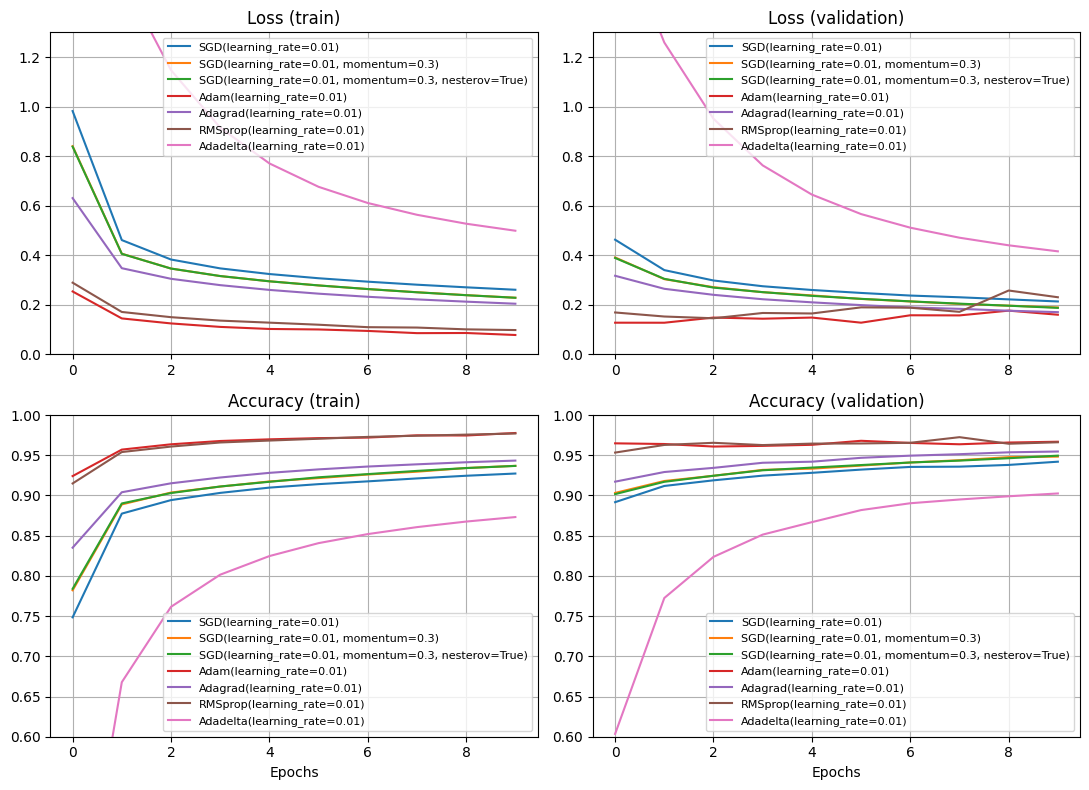

In [ ]:
legend_font = '8'
fig = plt.figure(figsize = (11,8))
ax = plt.subplot(221)
hxs = historydf.xs('loss', axis=1, level='metric')
hxs.plot(ylim=(0,1.3), ax=ax)
plt.title("Loss (train)")
plt.legend(fontsize=legend_font)
plt.grid()

ax = plt.subplot(222)
hxs = historydf.xs('val_loss', axis=1, level='metric')
hxs.plot(ylim=(0,1.3), ax=ax)
plt.title("Loss (validation)")
plt.legend(fontsize=legend_font)
plt.grid()

ax = plt.subplot(223)
hxs = historydf.xs('accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.6,1), ax=ax)
plt.title("Accuracy (train)")
plt.xlabel("Epochs")
plt.legend(fontsize=legend_font)
plt.grid()

ax = plt.subplot(224)
hxs = historydf.xs('val_accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.6,1), ax=ax)
plt.title("Accuracy (validation)")
plt.xlabel("Epochs")
plt.legend(fontsize=legend_font)
plt.grid()

plt.tight_layout()
plt.show()

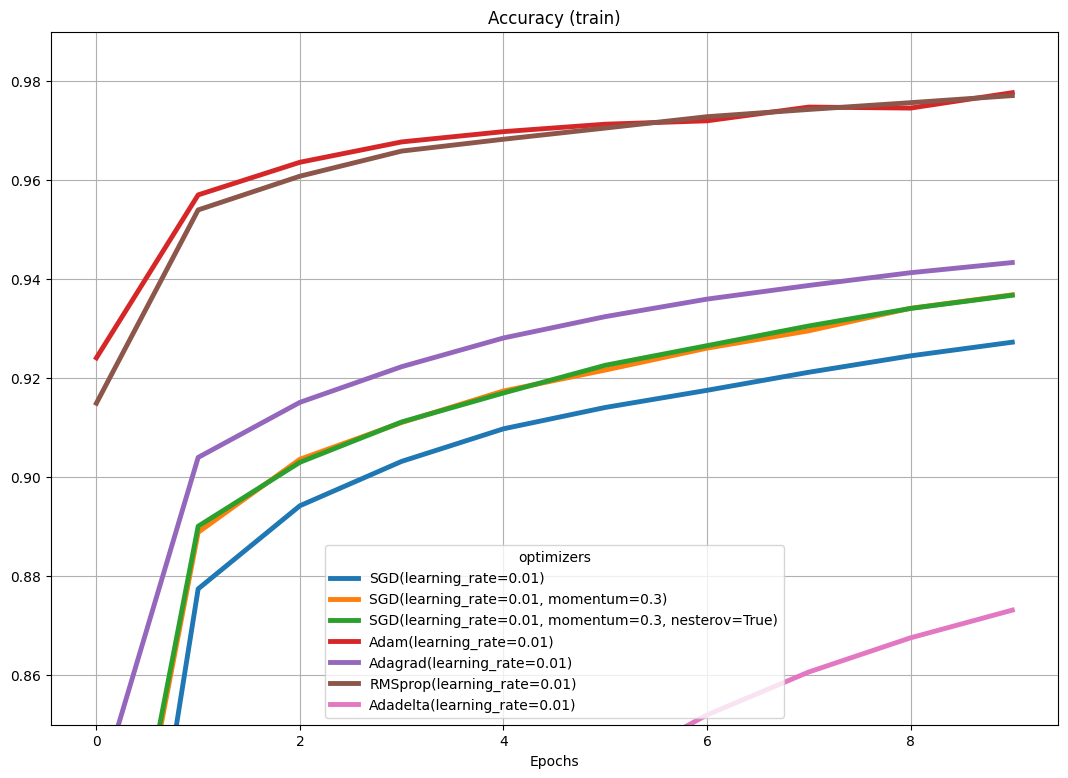

In [ ]:
# olhando os detalhes (zoom) das curvas das acurárias
hxs = historydf.xs('accuracy', axis=1, level='metric')
hxs.plot(ylim=(0.85,.99), figsize = (13,9),linewidth=3.5)
plt.title("Accuracy (train)")
plt.xlabel("Epochs")
plt.grid()
plt.show()

##Weights Initialization
So far we have explored the effect of learning rate, batch size, and optimizers on the speed of convergence of a model. We have compared their effect starting from the same set of randomly initialized weights. What if we initialized weights in a different weight and kept everything else fixed? This may seem unimportant, but it turns out that the initialization is critical. A model could not converge at all for some initialization and converge quickly for some other initialization. While we don't understand this fully, we have a few heuristic strategies available, that we can test, looking for the best one for our specific problem.

`keras` offers the possibility to initialize the weights in several ways including:

- Zeros, ones, constant: all weights initialized to zero, to one or a fixed value. Generally, these are not good choices, because they leave the model uncertain on which parameters to optimize first.

Initialization strategies try to "break the symmetry" by assigning random values to the parameters. The range and type of random distribution can vary, and several initialization schemes have are available:

- *Random uniform*: each weight receives a random value between 0 and 1, chosen with uniform probability.
- *Lecun_uniform*: like the above, but the values are drawn in the interval [-limit, limit] where limit is $\frac{\sqrt{3}}{\textrm{\# inputs}}$. Where $\textrm{\# inputs}$ indicates the number of inputs in the weight tensor for a specific layer.
- *Normal*: each weight receives a random value drawn from a normal distribution with mean 0 and standard deviation of 1.
- *He_normal*: like the previous one, but with standard deviation $\sigma = \sqrt{\frac{2}{\textrm{\# in}}}$.
- *Glorot_normal*: like the previous one, but with standard deviation  $\sigma = \sqrt{\frac{2}{\textrm{\# in} + \textrm{\# out}}}$.

You can read more about them [here](https://keras.io/initializers/). To see the effect of initialization, we'll use a deeper network with more than just five weights.

In [ ]:
dflist = []
start_time = time.process_time()
inits = ['zeros', 'ones', 'uniform', 'lecun_uniform', 'normal', 'he_normal', 'glorot_normal']
for init in inits:
  inter_time = time.process_time()
  K.clear_session()
  model = Sequential()
  model.add(Input((784,)))
  model.add(Dense(units=50, activation='relu', kernel_initializer=init))
  model.add(Dense(10, activation='softmax', kernel_initializer=init))
  model.compile(optimizer='sgd', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
  h = model.fit(X_train_sc, y_train, batch_size=64, epochs=10, verbose=0, validation_split=0.1)
  dflist.append(pd.DataFrame(h.history, index=h.epoch))
  print("Done: ", init)
  training_time_s = time.process_time() - inter_time
  training_time_m = training_time_s / 60
  print("Tempo: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento total: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Done:  zeros
Tempo: 26.79 segundos (0.45 minutos)
Done:  ones
Tempo: 26.45 segundos (0.44 minutos)
Done:  uniform
Tempo: 26.11 segundos (0.44 minutos)
Done:  lecun_uniform
Tempo: 26.44 segundos (0.44 minutos)
Done:  normal
Tempo: 26.59 segundos (0.44 minutos)
Done:  he_normal
Tempo: 26.35 segundos (0.44 minutos)
Done:  glorot_normal
Tempo: 26.22 segundos (0.44 minutos)

Tempo de treinamento total: 184.96 segundos (3.08 minutos)


Let's aggregate and plot the results

In [ ]:
historydf = pd.concat(dflist, axis=1)
metrics_ = dflist[0].columns
idx = pd.MultiIndex.from_product([inits, metrics_], names=['initializers', 'metric'])
historydf.columns = idx

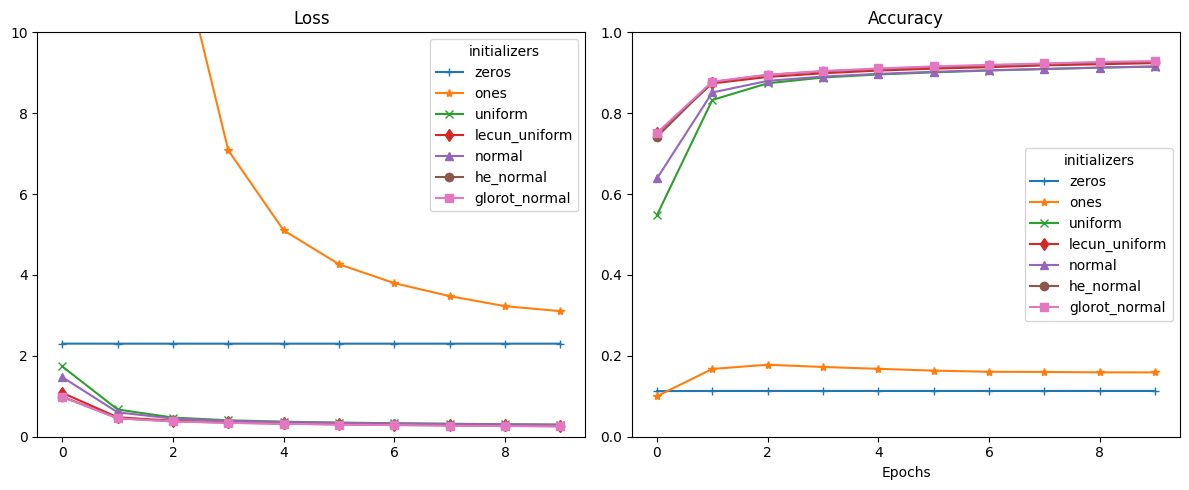

In [ ]:
styles = ['-+', '-*', '-x', '-d', '-^', '-o', '-s']
plt.figure(figsize=(12, 5))

ax = plt.subplot(121)
xs = historydf.xs('loss', axis=1, level='metric')
xs.plot(ylim=(0,10), ax=ax, style=styles)
plt.title("Loss")

ax = plt.subplot(122)
xs = historydf.xs('accuracy', axis=1, level='metric')
xs.plot(ylim=(0,1), ax=ax, style=styles)
plt.title("Accuracy")
plt.xlabel("Epochs")

plt.tight_layout()
plt.show()

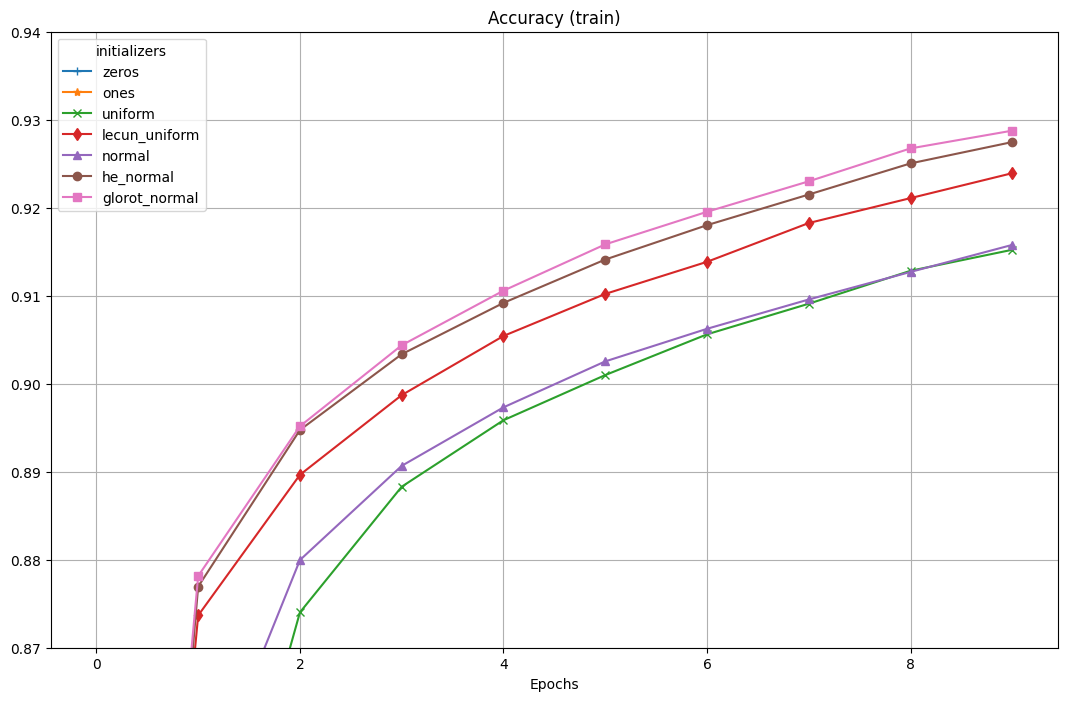

In [ ]:
# olhando com detalhes as curvas das acurárias
styles = ['-+', '-*', '-x', '-d', '-^', '-o', '-s']
xs = historydf.xs('accuracy', axis=1, level='metric')
xs.plot(ylim=(0.87,0.94), style=styles, linewidth=1.5, figsize=(13, 8))
plt.title("Accuracy (train)")
plt.xlabel("Epochs")
plt.grid()
plt.show()

As you can see some initializations don't even converge, while some do converge rather quickly. Initialization of the weights plays a significant role in large models, so it is important to try a couple of different initialization schemes to get the best results.

##Novo modelo de rede
Modelo de rede mantendo-se a arquitetura inicial e ecolhendo os hiperparâmetros de melhores desempenho nos testes:
- otimizador: Adam
- learning_rate: 0.01 (mantendo-se o mesmo dos testes)
- batch_size = 64
- epochs = 10

In [11]:
# inicializa a sessão
K.clear_session()
# inicialização do modelo
model2 = Sequential(name='rede2')
# camada de entrada = 784 neurônios
model2.add(Input((784,), name='input'))
# primeira hidden layer = 50 neurônios e função de ativação = relu
model2.add(Dense(units = 50, activation = 'relu', name='layer1'))
# camada de saída
model2.add(Dense(10, activation='softmax', name='output'))
# sumário do modelo da rede
model2.summary()

Model: "rede2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.optimizers import Adam
# Compilação do novo modelo
optimizer_ = Adam(learning_rate = 0.01)
model2.compile(optimizer = optimizer_, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
weights2 = model2.get_weights()

In [ ]:
import time
start_time = time.process_time()
# carrega os pesos e bias com os valores inicias, para um novo treinamento da rede
model2.set_weights(weights2)
# treinamento da rede
h = model2.fit(X_train_sc, y_train, batch_size=64, epochs=10, verbose=1, validation_split=0.1)
training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento da rede: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9173 - loss: 0.2756 - val_accuracy: 0.9570 - val_loss: 0.1543
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9519 - loss: 0.1550 - val_accuracy: 0.9625 - val_loss: 0.1380
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9599 - loss: 0.1327 - val_accuracy: 0.9653 - val_loss: 0.1242
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9650 - loss: 0.1173 - val_accuracy: 0.9660 - val_loss: 0.1244
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9672 - loss: 0.1086 - val_accuracy: 0.9600 - val_loss: 0.1548
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9677 - loss: 0.1060 - val_accuracy: 0.9608 - val_loss: 0.1658
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9718 - loss: 0.0941 - val_accuracy: 0.9613 - val_loss: 0.1625
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9711 - loss: 0.0985 - val_accuracy: 0.

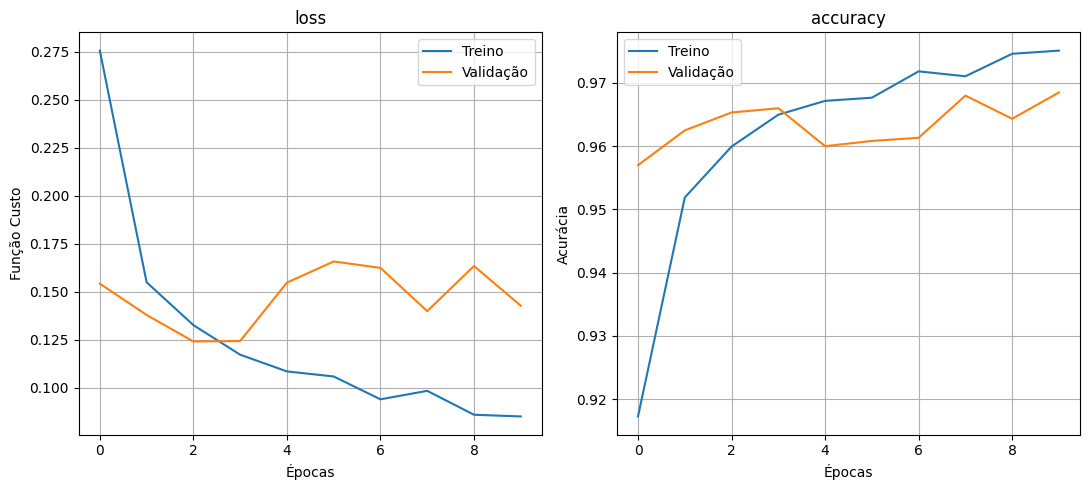

In [ ]:
plot_graphs()

In [ ]:
from sklearn.metrics import accuracy_score
# utilizando o modelo treinado para fazer as predições no banco de dados de testes
prediction = model2.predict(X_test_sc)
y_predict = np.argmax(prediction,axis=1)
# cálculo da acurrácia
acc = accuracy_score(y_test, y_predict)
print(f'acurárica: {acc*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
acurárica: 96.24%


### Análise dos resultados do treinamento — MNIST

- Convergência: a função de custo do treinamento diminui de aproximadamente 0,275 para 0,085, indicando aprendizado consistente.
- Desempenho: a acurácia final é de aproximadamente 97,5% no treinamento e 96,8% na validação, resultados elevados para a classificação dos dígitos MNIST.
- Generalização: a pequena diferença entre as acurácias indica boa capacidade de generalização.
- **Overfitting**: observa-se possível sobreajuste a partir da 4ª época, quando a perda de validação aumenta e oscila, enquanto a perda de treinamento continua diminuindo.
- Melhoria: recomenda-se utilizar Early Stopping, monitorando a perda de validação, para interromper o treinamento quando não houver melhora.

Conclusão: a rede apresenta excelente desempenho e boa generalização, com acurácia de validação próxima de 97%. Entretanto, o aumento e as oscilações da perda de validação sugerem monitorar o sobreajuste e selecionar a época com melhor desempenho de validação.

##Modelo de rede otimizado
Modelo de rede otimizado mantendo-se a arquitetura inicial mas adotando novos hiperparâmetros para buscar melhores desempenho:
- otimizador: Adam
- learning_rate: 0.001 (para evitar overfitting)
- batch_size = 64
- epochs = 20 (maior tempo de treinamento)

In [13]:
# inicializa a sessão
K.clear_session()
# inicialização do modelo
model3 = Sequential(name='rede3')
# camada de entrada = 784 neurônios
model3.add(Input((784,), name='input'))
# primeira hidden layer = 50 neurônios e função de ativação = relu
model3.add(Dense(units = 50, activation = 'relu', name='layer1'))
# camada de saída
model3.add(Dense(10, activation='softmax', name='output'))
# sumário do modelo da rede
model3.summary()

Model: "rede3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
optimizer_ = Adam(learning_rate = 0.001)
model3.compile(optimizer = optimizer_, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
weights3 = model3.get_weights()

In [20]:
import time
start_time = time.process_time()
model3.set_weights(weights3)
h = model3.fit(X_train_sc, y_train, batch_size=64, epochs=20, verbose=1, validation_split=0.1)
training_time_s = time.process_time() - start_time
training_time_m = training_time_s / 60
print("\nTempo de treinamento da rede: %.2f segundos (%.2f minutos)" % (training_time_s, training_time_m))

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8889 - loss: 0.4024 - val_accuracy: 0.9468 - val_loss: 0.1917
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9403 - loss: 0.2097 - val_accuracy: 0.9593 - val_loss: 0.1501
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9532 - loss: 0.1631 - val_accuracy: 0.9665 - val_loss: 0.1301
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9608 - loss: 0.1336 - val_accuracy: 0.9672 - val_loss: 0.1157
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9661 - loss: 0.1144 - val_accuracy: 0.9678 - val_loss: 0.1133
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9706 - loss: 0.1002 - val_accuracy: 0.9705 - val_loss: 0.1023
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9751 - loss: 0.0874 - val_accuracy: 0.9680 - val_loss: 0.1075
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9766 - loss: 0.0776 - val_accuracy: 0.

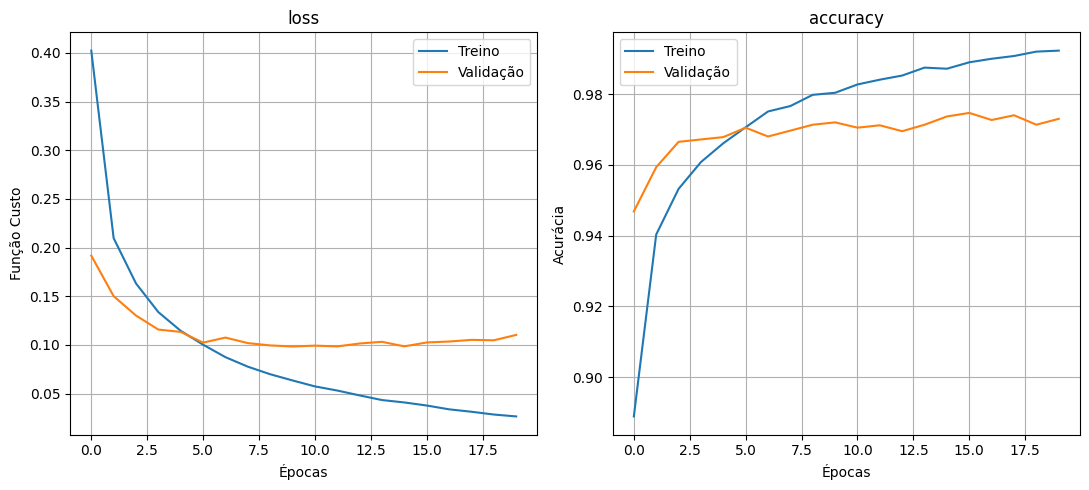

In [23]:
plot_graphs()

In [24]:
from sklearn.metrics import accuracy_score
# utilizando o modelo treinado para fazer as predições no banco de dados de testes
prediction = model3.predict(X_test_sc)
y_predict = np.argmax(prediction,axis=1)
# cálculo da acurrácia
acc = accuracy_score(y_test, y_predict)
print(f'acurárica: {acc*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
acurárica: 97.19%


### Análise dos resultados do treinamento — MNIST

**Configuração:** O modelo foi treinado no dataset MNIST (classificação de dígitos) por 20 épocas.

**Diagnóstico:** O modelo apresenta **Overfitting (Sobreajuste)**.

**Evidências e Análise:**

1.  **Loss (Função Custo):**
    *   **Treino (Azul):** Continua caindo consistentemente até o final, atingindo valores muito baixos (~0.02), indicando que o modelo decorou os dados de treino.
    *   **Validação (Laranja):** Estabiliza por volta da época 7-10 (em ~0.10) e começa a oscilar levemente, sem melhorar significativamente depois disso.

2.  **Accuracy (Acurácia):**
    *   **Treino (Azul):** Atinge quase 99% (>0.985), mostrando performance quase perfeita nos dados vistos.
    *   **Validação (Laranja):** Estaciona em torno de 97,5% a partir da época 5. A partir da época 8, a curva fica "plana", e a diferença (gap) entre a linha de treino e validação aumenta visivelmente.

**Conclusão:**
O modelo aprendeu bem as características gerais até a **época 5-7**. Após esse ponto, ele começou a memorizar ruídos e particularidades do conjunto de treino, perdendo capacidade de generalização. Para corrigir isso, recomenda-se aplicar **Early Stopping** (parar por volta da época 7) ou utilizar técnicas de regularização (Dropout, L2) que serão vistos nas próximas aulas!!

O resultado das predições nesta rede neural em que se utiliza a função loss='*sparse_categorical_crossentropy*' são valores probabilisticos de confiança, onde o maior valor é a maior probabilidade (confiança) de reultado positivo. Assim, como os labels do banco de dados vão de 0 à 9, a posição de maior valor numérico nas linhas da matriz de predição vão indicar o label correspondente, como maior probalidade de acerto.

In [25]:
amostra = 10;
print('y_prediction[amostra] =', prediction[amostra])
print('Soma dos valores de predição da amostra:', prediction[amostra].sum())
print('Posição do maior valor numérico:', prediction[amostra].argmax())
print('Probalidade da predição (confiança): %.3f%%' %(prediction[amostra].max()*100))
print('Label y_test[amostra] =', y_test[amostra])

y_prediction[amostra] = [9.9974370e-01 2.0499977e-09 8.1197113e-06 3.4036140e-07 3.3751183e-14
 1.0680602e-05 4.5104382e-08 1.2720935e-09 8.9398764e-09 2.3708124e-04]
Soma dos valores de predição da amostra: 1.0
Posição do maior valor numérico: 0
Probalidade da predição (confiança): 99.974%
Label y_test[amostra] = 0


In [26]:
y_predict = np.argmax(prediction,axis=1)
y_predict

array([7, 2, 1, ..., 4, 5, 6])

In [27]:
# matriz de confusão simples
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, y_predict)
print(confusion)

[[ 963    1    2    1    1    5    2    2    1    2]
 [   0 1123    4    2    0    1    2    0    3    0]
 [   3    3 1008    5    1    0    2    5    3    2]
 [   0    0    3  982    0   10    0    7    2    6]
 [   0    0    4    1  956    0    4    2    1   14]
 [   4    0    0    9    1  869    4    2    2    1]
 [   4    2    4    2    8    7  929    0    2    0]
 [   0    7   13    4    0    0    0  994    2    8]
 [   3    1   11   15    8    7    2    6  916    5]
 [   1    4    0    4   12    3    1    3    2  979]]


In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.97      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.94      0.96       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [29]:
# função para visualização das predições (examples: 28*28 pixels)
def show_predict(examples, targets, predict_):
    init = 0
    plt.figure(figsize=(10, 10))

    for i in range(64):
        plt.subplot(8, 8, i+1)
        plt.imshow(examples[init + i], cmap='Greys')
        plt.xlabel(f'y: {targets[init + i]} - ŷ: {predict_[init + i]}', size = 9)
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

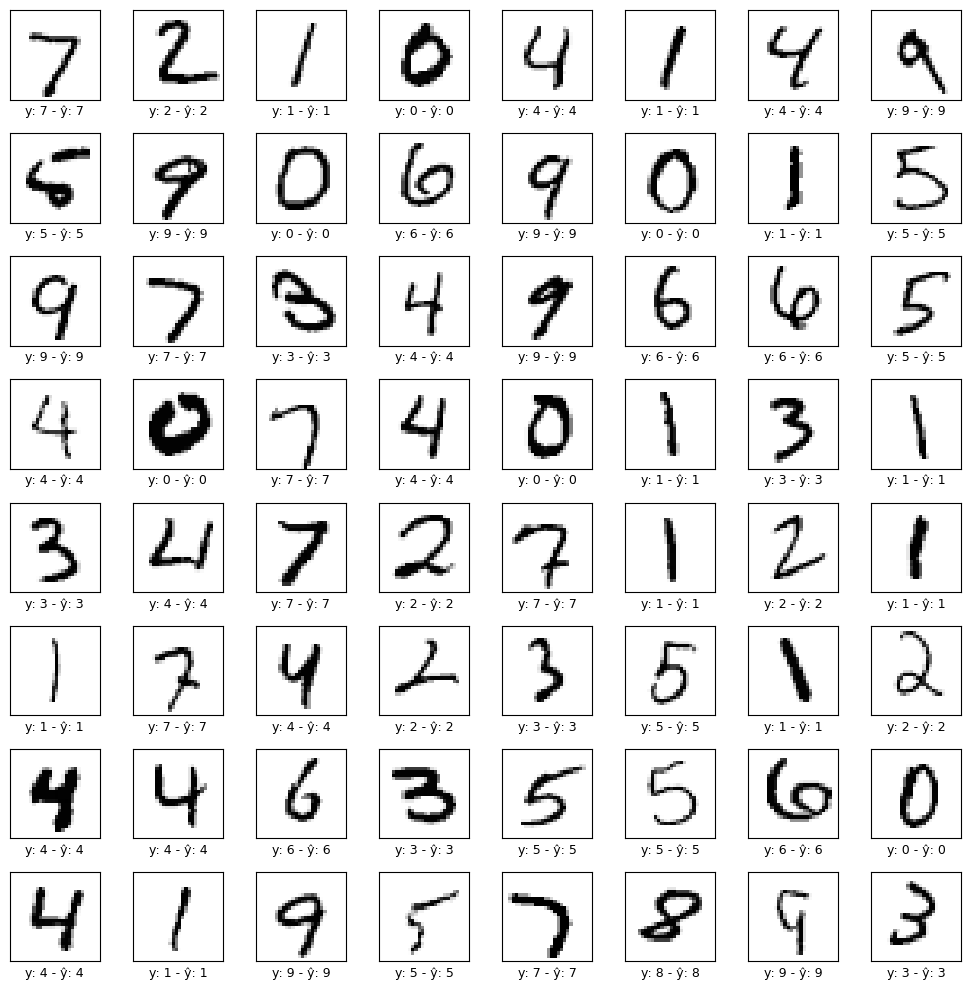

In [30]:
# as primeiras amostras de imagens do banco de dados de teste com suas predições
show_predict(X_test, y_test, y_predict)

# Predições com novos dígitos

Podemos fazer o teste na nossa rede, para ver se vai predizer corretamente os dígitos que nós escrevermos. Para isso, utilize Paint e escreva números de 0 a 9. Salve no drive (0.png, 1.png, ..., 9.png) e rode novamente a predição para verificar se a rede treinada consegue predizer corretamente os novos dígitos.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
from numpy import asarray
from PIL import Image
# Local  das imagens de 10 dígitos feitos no paint (0.png, 1.png...., 9.png)
path='/content/drive/MyDrive/Colab Notebooks/images/'
# Crio uma cópia nova do banco de dados de teste, sem que aponte para o mesmo objecto:
X_test_new = np.copy(X_test)
X_test_flat_new = np.copy(X_test_flat)
X_test_sc_new = np.copy(X_test_sc)
y_test_new = np.copy(y_test)
# Carregando as imagens (0.png, 1.png...., 9.png)
for i in range(10):
  img_num=str(i)+'.png'
  img1=Image.open(path + img_num)
  img1.thumbnail((28,28))
  img2=img1.convert(mode='L')
  img3=asarray(img2)
  img3 = 255 - img3
  # salvo as 10 imagens novas nas primeiras posições de X_test_new
  X_test_new[i] = img3
  X_test_flat_new[i] = X_test_new[i].reshape(-1, 28*28)
  X_test_sc_new[i] = X_test_flat_new[i] / 255
  y_test_new[i] = i

A figura mostra a predição dos dígitos criados e inseridos no banco de dados de teste.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


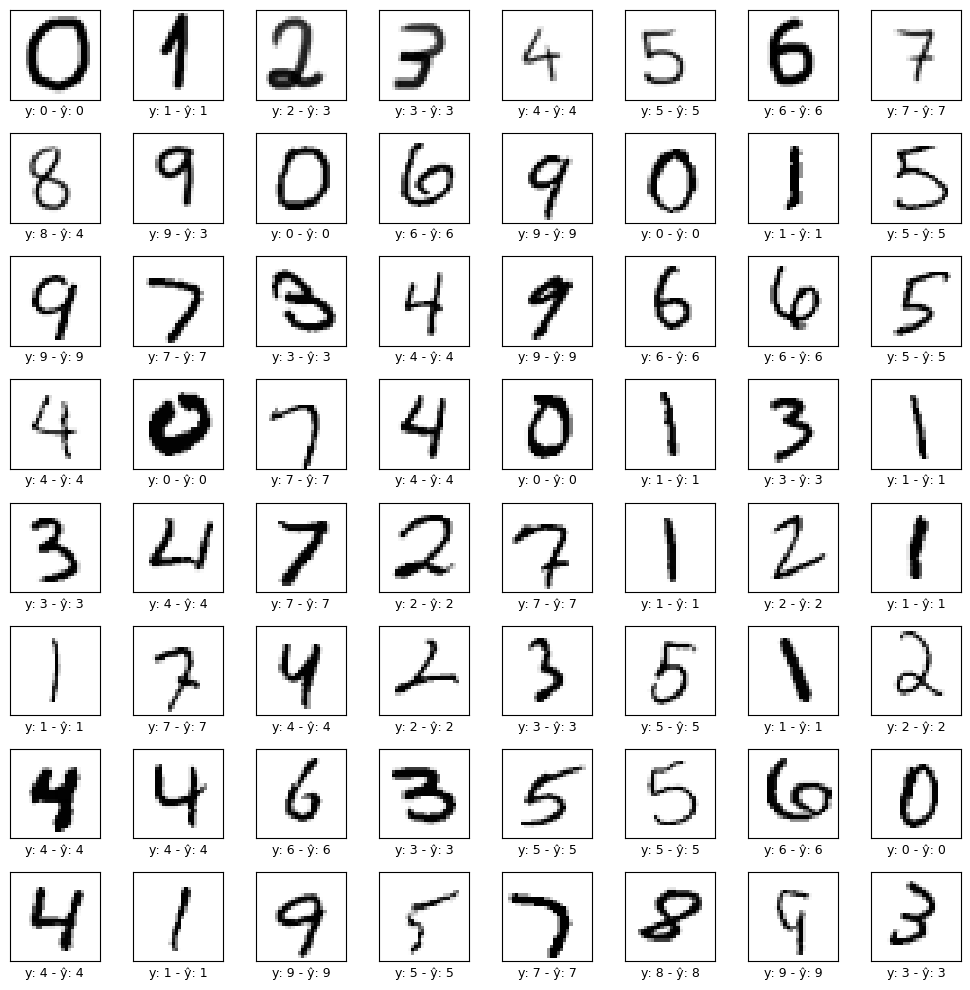

In [39]:
# predição dos 10 dígitos feitos no paint com o último modelo de rede treinado
prediction_new = model3.predict(X_test_sc_new)
y_predict_new = np.argmax(prediction_new,axis=1)
show_predict(X_test_new, y_test_new, y_predict_new)

In [41]:
# verificando a probabilidade de acerto/erro da previsão
amostra = 2;
print('y_predict_new[amostra] =', prediction_new[amostra])
print('Soma dos valores de predição da amostra:', prediction_new[amostra].sum())
print('Posição do maior valor numérico:', prediction_new[amostra].argmax())
print('Probalidade da predição (confiança): %.3f%%' %(prediction_new[amostra].max()*100))
print('Label y_test_new[amostra] =', y_test_new[amostra])

y_predict_new[amostra] = [1.4328130e-20 1.4804915e-06 5.7001963e-02 9.4299650e-01 2.0548300e-28
 1.4009513e-10 2.4278642e-24 3.3958730e-23 6.4060840e-12 4.9430802e-22]
Soma dos valores de predição da amostra: 0.99999994
Posição do maior valor numérico: 3
Probalidade da predição (confiança): 94.300%
Label y_test_new[amostra] = 2


## Exercises
1) Keras offers the possibility to call a function at each epoch. These are Callbacks, and their [documentation is here](https://keras.io/callbacks/). Callbacks allow us to add some neat functionality. In this exercise, we'll explore a few of them.

- build a deep fully connected network with the following structure:
    - Input Layer: 784 nodes
    - Hidden Layer 1: 200 nodes
    - Hidden Layer 2: 100 nodes
    - Output Layer: 10 nodes
- choose activation functions, initializations, optimizer, learning rate and batch size so that it best converges to 100% accuracy (training and validation dataset) within 20 epochs (not easy)
- remember to train the model on the scaled data
- train the model on the train data using `validation_data=0.1`
- Use the `EarlyStopping` callback to stop your training if the `val_loss` doesn't improve
- Use the `ModelCheckpoint` callback to save the trained model to disk once training is over

2) Monte um banco de dados com 50 amostras de dígitos feitos no papel branco com caneta marcadora preto, escritos por 5 pessoas distintas. Fotografe as amostras e retrabalhe a imagem, retirando somente a área do dígito e deixando-a no formato quadrado 500x500 pixels. Teste as predições do seu banco de testes com a rede em sua melhor configuração e sintonia. Tire suas conclusões.

# Referências

[1] https://www.deeplearningbook.com.br/algoritmo-backpropagation-parte-2-treinamento-de-redes-neurais/

[2] https://www.upgrad.com/blog/types-of-optimizers-in-deep-learning/

[3] https://medium.com/mlearning-ai/optimizers-in-deep-learning-7bf81fed78a0

[4] https://www.scaler.com/topics/deep-learning/optimizers-in-deep-learning/

[5] Mosconi, Francesco. *Zero to Deep Learning*. Catalit LLC, 2019.

[6] https://machinelearningmastery.com/how-to-develop-a-convolutional-neural-network-from-scratch-for-mnist-handwritten-digit-classification/

[7] https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras

[8] https://medium.com/tebs-lab/how-to-classify-mnist-digits-with-different-neural-network-architectures-39c75a0f03e3

[9] https://www.kaggle.com/code/heeraldedhia/mnist-classifier-first-deep-learning-project

[10] https://towardsdatascience.com/image-classification-in-10-minutes-with-mnist-dataset-54c35b77a38d

[11] https://www.tensorflow.org/api_docs/python/tf/keras/Sequential